# 1. Ответы на вопросы (Answer the questions)

1.1. Аналитическое решение отличается тем, что вместо градиентного спуска мы находим коэффициенты признаков, дающих минимум функции потерь, взяв от нее производную и приравняв к нулю. Уравнение в векторной форме:

$$\hat{\theta} = (X^T X)^{-1} X^T y$$

1.2. В случае L1 и L2 регуляризации в функцию потерь добавляется дополнительный термин:

$$min_\theta = \sum_{i=1}^N L(f(x_i,\theta), y_i) + \lambda R(\theta)$$

1.3. L1 (Lasso-регуляризация) хорошо используется для отбора значимых признаков - слабо влияющие на целевую переменную признаки обнуляются благодаря штрафу $R(\theta)=\sum_{i=1}^d |\theta_i|$

1.4. Чтобы обучать эти же модели при нелинейных зависимостях, нужно задействовать нелинейные преобразования признаков (уравнение останется линейным по коэффициентам и свободному члену), вроде полиномиальных признаков, логарифмирования, экспоненцирования и т.п.

# 2. Введение (Introduction — make all the preprocessing staff from the previous lesson)

## 2.1. Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error
from collections import Counter

## 2.2. Загрузка и предобработка данных

In [122]:
df_full = pd.read_json('data/train.json')
print(f"Размер: {df_full.shape}")
print(f"Типы данных:\n{df_full.dtypes}")
df_full.head()

Размер: (49352, 15)
Типы данных:
bathrooms          float64
bedrooms             int64
building_id            str
created                str
description            str
display_address        str
features            object
latitude           float64
listing_id           int64
longitude          float64
manager_id             str
photos              object
price                int64
street_address         str
interest_level         str
dtype: object


,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


In [123]:
p1 = df_full['price'].quantile(0.01)
p99 = df_full['price'].quantile(0.99)
print(f"1-й перцентиль: {p1}, 99-й перцентиль: {p99}")

df_full = df_full[(df_full['price'] > p1) & (df_full['price'] < p99)]
print(f"Размер данных после удаления выбросов: {df_full.shape}")

1-й перцентиль: 1475.0, 99-й перцентиль: 13000.0
Размер данных после удаления выбросов: (48343, 15)


# 3. Введение в анализ данных - Часть 2 (Intro data analysis part 2)

## 3.1-4. Обработка столбца features

In [124]:
all_features = []
for _, row in df_full.iterrows():
    for feat in row['features']:
        cleaned = feat.replace(' ', '').replace('[', '').replace(']', '').replace("'", '').replace('"', '')
        if cleaned:
            all_features.append(cleaned)

print(f"Общее количество значений в списке: {len(all_features)}")
print(f"Количество уникальных значений: {len(set(all_features))}")

Общее количество значений в списке: 262377
Количество уникальных значений: 1529


## 3.5-7. Задействование библиотеки collections для подсчета популярных признаков

In [125]:
feature_counts = Counter(all_features)
top_20_features = feature_counts.most_common(20)

print("Топ-20 самых популярных характеристик квартир:\n")
for i, (feat, count) in enumerate(top_20_features, 1):
    print(f"{i}. {feat} - {count}")

Топ-20 самых популярных характеристик квартир:

1. Elevator - 25375
2. HardwoodFloors - 23146
3. CatsAllowed - 23135
4. DogsAllowed - 21652
5. Doorman - 20479
6. Dishwasher - 20081
7. NoFee - 17793
8. LaundryinBuilding - 16082
9. FitnessCenter - 12989
10. Pre-War - 8971
11. LaundryinUnit - 8437
12. RoofDeck - 6417
13. OutdoorSpace - 5132
14. DiningRoom - 4890
15. HighSpeedInternet - 4223
16. Balcony - 2898
17. SwimmingPool - 2643
18. LaundryInBuilding - 2564
19. NewConstruction - 2504
20. Terrace - 2177


## 3.8-9. Создание бинарных признаков и формирование набора из 22 признаков

In [126]:
top_20_names = [feat for feat, _ in top_20_features]

for feature_name in top_20_names:
    df_full[feature_name] = df_full['features'].apply(
        lambda x: 1 if feature_name in [
            f.replace(' ', '').replace('[', '').replace(']', '').replace("'", '').replace('"', '') for f in x
        ] else 0
    )

feature_list = ['bathrooms', 'bedrooms'] + top_20_names
print(f"Количество признаков: {len(feature_list)}")
print(f"\nСписок:")
for i, f in enumerate(feature_list, 1):
    print(f"{i}. {f}")

Количество признаков: 22

Список:
1. bathrooms
2. bedrooms
3. Elevator
4. HardwoodFloors
5. CatsAllowed
6. DogsAllowed
7. Doorman
8. Dishwasher
9. NoFee
10. LaundryinBuilding
11. FitnessCenter
12. Pre-War
13. LaundryinUnit
14. RoofDeck
15. OutdoorSpace
16. DiningRoom
17. HighSpeedInternet
18. Balcony
19. SwimmingPool
20. LaundryInBuilding
21. NewConstruction
22. Terrace


In [127]:
X = df_full[feature_list]
y = df_full['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Обучающая выборка: X_train {X_train.shape}, y_train {len(y_train)}")
print(f"Тестовая выборка: X_test {X_test.shape}, y_test {len(y_test)}")

Обучающая выборка: X_train (38674, 22), y_train 38674
Тестовая выборка: X_test (9669, 22), y_test 9669


# 4. Реализация моделей - линейная регрессия (Models implementation - Linear regression)

## 4.1. Создание класса, воспроизводящего алгоритм линейной регрессии + аналитическое решение и полный (нестохастический) градиентный спуск

In [128]:
class MyLinearRegression:

    def __init__(self, learning_rate=0.01, n_epochs=100, random_state=42):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.random_state = random_state
        self.weights = None
        self.bias = None

    def _penalty_grad(self, w, alpha_scaled):
        return 0.0

    def fit(self, X, y):
        np.random.seed(self.random_state)
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.float64)
        n_samples, n_features = X.shape

        w = np.zeros(n_features)
        b = 0.0
        alpha_scaled = getattr(self, 'alpha', 0.0) / n_samples

        for _ in range(self.n_epochs):
            indices = np.random.permutation(n_samples)
            for i in indices:
                y_pred = X[i].dot(w) + b
                error = y_pred - y[i]
                w -= self.learning_rate * (error * X[i] + self._penalty_grad(w, alpha_scaled))
                b -= self.learning_rate * error

        self.weights = w
        self.bias = b
        return self

    def predict(self, X):
        X = np.array(X, dtype=np.float64)
        return X.dot(self.weights) + self.bias

In [129]:
class MyLinearRegressionAnalytical(MyLinearRegression):

    def __init__(self):
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.float64)
        X_b = np.c_[np.ones(X.shape[0]), X]
        theta = np.linalg.pinv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        self.bias = theta[0]
        self.weights = theta[1:]
        return self


class MyLinearRegressionGD(MyLinearRegression):

    def __init__(self, learning_rate=0.01, n_epochs=100, random_state=42):
        super().__init__(learning_rate=learning_rate, n_epochs=n_epochs, random_state=random_state)

    def fit(self, X, y):
        np.random.seed(self.random_state)
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.float64)
        n_samples, n_features = X.shape

        w = np.zeros(n_features)
        b = 0.0

        for _ in range(self.n_epochs):
            y_pred = X.dot(w) + b
            errors = y_pred - y
            w -= self.learning_rate * (2 / n_samples) * X.T.dot(errors)
            b -= self.learning_rate * (2 / n_samples) * errors.sum()

        self.weights = w
        self.bias = b
        return self


## 4.2. Что такое детерминистическая модель?

**Детерминистическая модель** - модель, которая при одних и тех же входных данных **всегда** выдаёт одинаковый результат.

В SGD (стохастическом градиентном спуске) случайность возникает из-за перемешивания данных на каждой эпохе. Чтобы сделать SGD детерминистическим, нужно зафиксировать зерно (seed) генератора случайных чисел (random_state / np.random.seed). Тогда порядок обхода данных будет одинаковым при каждом запуске, и модель гарантированно даст те же веса.

## 4.3. Коэффициент детерминации $R^2$ и функции метрик

**Коэффициент $R^2$** (R-squared, коэффициент детерминации) отражает качество предсказательной функции модели и вычисляется по формуле:

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

- $R^2 = 1$ - идеальное предсказание  
- $R^2 = 0$ - модель не лучше предсказания средним
- $R^2 < 0$ - модель хуже, чем предсказание средним
- $R^2 > 0$ & $R^2 < 1$ - не идеальные, но и не совсем плохие предсказания (обычно хороший показатель - $R^2 > 0.60$, хотя это зависит от области)

In [130]:
def r2_score_custom(y_true, y_pred):
    return 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)

In [131]:
results_mae = {'model': [], 'train': [], 'test': []}
results_rmse = {'model': [], 'train': [], 'test': []}
results_r2  = {'model': [], 'train': [], 'test': []}

def add_metrics(name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    results_mae['model'].append(name)
    results_mae['train'].append(mean_absolute_error(y_train_true, y_train_pred))
    results_mae['test'].append(mean_absolute_error(y_test_true, y_test_pred))

    results_rmse['model'].append(name)
    results_rmse['train'].append(np.sqrt(mean_squared_error(y_train_true, y_train_pred)))
    results_rmse['test'].append(np.sqrt(mean_squared_error(y_test_true, y_test_pred)))

    results_r2['model'].append(name)
    results_r2['train'].append(r2_score_custom(y_train_true, y_train_pred))
    results_r2['test'].append(r2_score_custom(y_test_true, y_test_pred))

def print_metrics_dataframe():
    print('Таблица MAE:')
    display(pd.DataFrame(results_mae))
    print('\nТаблица RMSE:')
    display(pd.DataFrame(results_rmse))
    print('\nТаблица R^2:')
    display(pd.DataFrame(results_r2))


## 4.4-5. Обучение и оценка линейной регрессии - из sklearn и моей

In [132]:
my_lr = MyLinearRegression().fit(X_train, y_train)
y_train_pred_my = my_lr.predict(X_train)
y_test_pred_my = my_lr.predict(X_test)

In [133]:
sk_lr = LinearRegression().fit(X_train, y_train)
y_train_pred_sk = sk_lr.predict(X_train)
y_test_pred_sk = sk_lr.predict(X_test)

## 4.6. Сравнение показателей метрик

In [134]:
print("\nРазница между реализациями:")
print(f"MAE (test): {abs(mean_absolute_error(y_test, y_test_pred_my) - mean_absolute_error(y_test, y_test_pred_sk))}")
print(f"RMSE (test): {abs(np.sqrt(mean_squared_error(y_test, y_test_pred_my)) - np.sqrt(mean_squared_error(y_test, y_test_pred_sk)))}")
print(f"R^2 (test): {abs(r2_score_custom(y_test, y_test_pred_my) - r2_score_custom(y_test, y_test_pred_sk))}")


Разница между реализациями:
MAE (test): 6.159606951458386
RMSE (test): 7.681367913389522
R^2 (test): 0.006486905452608327


## 4.7. Таблицы показателей метрик

In [135]:
add_metrics('Моя линейная регрессия (SGD)', y_train, y_train_pred_my, y_test, y_test_pred_my)
add_metrics('Линейная регрессия sklearn', y_train, y_train_pred_sk, y_test, y_test_pred_sk)

print_metrics_dataframe()

Таблица MAE:


,model,train,test
0,Моя линейная регрессия (SGD),713.312606,717.714093
1,Линейная регрессия sklearn,707.909104,711.554486



Таблица RMSE:


,model,train,test
0,Моя линейная регрессия (SGD),1029.707959,1048.684380
1,Линейная регрессия sklearn,1023.913834,1041.003012



Таблица R^2:


,model,train,test
0,Моя линейная регрессия (SGD),0.579913,0.555566
1,Линейная регрессия sklearn,0.584628,0.562053


# 5. Реализация регуляризованных моделей - Ridge, Lasso, ElasticNet (Regularized models implementation - Ridge, Lasso, ElasticNet)

## 5.1. Реализация алгоритмов регуляризации

In [136]:
class MyRidge(MyLinearRegression):

    def __init__(self, alpha=1.0, learning_rate=0.01, n_epochs=100, random_state=42):
        super().__init__(learning_rate=learning_rate, n_epochs=n_epochs, random_state=random_state)
        self.alpha = alpha

    def _penalty_grad(self, w, alpha_scaled):
        return 2 * alpha_scaled * w


class MyLasso(MyLinearRegression):

    def __init__(self, alpha=1.0, learning_rate=0.01, n_epochs=100, random_state=42):
        super().__init__(learning_rate=learning_rate, n_epochs=n_epochs, random_state=random_state)
        self.alpha = alpha

    def _penalty_grad(self, w, alpha_scaled):
        return alpha_scaled * np.sign(w)


class MyElasticNet(MyLinearRegression):

    def __init__(self, alpha=1.0, l1_ratio=0.5, learning_rate=0.01, n_epochs=100, random_state=42):
        super().__init__(learning_rate=learning_rate, n_epochs=n_epochs, random_state=random_state)
        self.alpha = alpha
        self.l1_ratio = l1_ratio

    def _penalty_grad(self, w, alpha_scaled):
        return alpha_scaled * self.l1_ratio * np.sign(w) + alpha_scaled * (1 - self.l1_ratio) * 2 * w


## 5.2. Обучение моих регуляризованных моделей

In [137]:
my_ridge = MyRidge().fit(X_train, y_train)
y_train_pred_my_r = my_ridge.predict(X_train)
y_test_pred_my_r = my_ridge.predict(X_test)

my_lasso = MyLasso().fit(X_train, y_train)
y_train_pred_my_l = my_lasso.predict(X_train)
y_test_pred_my_l = my_lasso.predict(X_test)

my_elastic = MyElasticNet().fit(X_train, y_train)
y_train_pred_my_el = my_elastic.predict(X_train)
y_test_pred_my_el = my_elastic.predict(X_test)

## 5.3. sklearn-реализации регуляризованных моделей для сравнения

In [138]:
sk_ridge = Ridge(alpha=1.0, random_state=42).fit(X_train, y_train)
y_train_pred_sk_r = sk_ridge.predict(X_train)
y_test_pred_sk_r = sk_ridge.predict(X_test)

sk_lasso = Lasso(alpha=1.0, random_state=42, max_iter=10000).fit(X_train, y_train)
y_train_pred_sk_l = sk_lasso.predict(X_train)
y_test_pred_sk_l = sk_lasso.predict(X_test)

sk_elastic = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000).fit(X_train, y_train)
y_train_pred_sk_el = sk_elastic.predict(X_train)
y_test_pred_sk_el = sk_elastic.predict(X_test)

# 5.4. Сравнение показателей метрик 

In [139]:
print("\nРазница между реализациями:")
print(f"MAE Lasso (test): {abs(mean_absolute_error(y_test, y_test_pred_my_l) - mean_absolute_error(y_test, y_test_pred_sk_l))}")
print(f"RMSE Lasso (test): {abs(np.sqrt(mean_squared_error(y_test, y_test_pred_my_l)) - np.sqrt(mean_squared_error(y_test, y_test_pred_sk_l)))}")
print(f"R^2 Lasso (test): {abs(r2_score_custom(y_test, y_test_pred_my_l) - r2_score_custom(y_test, y_test_pred_sk_l))}\n")

print(f"MAE Ridge (test): {abs(mean_absolute_error(y_test, y_test_pred_my_r) - mean_absolute_error(y_test, y_test_pred_sk_r))}")
print(f"RMSE Ridge (test): {abs(np.sqrt(mean_squared_error(y_test, y_test_pred_my_r)) - np.sqrt(mean_squared_error(y_test, y_test_pred_sk_r)))}")
print(f"R^2 Ridge (test): {abs(r2_score_custom(y_test, y_test_pred_my_r) - r2_score_custom(y_test, y_test_pred_sk_r))}\n")

print(f"MAE ElasticNet (test): {abs(mean_absolute_error(y_test, y_test_pred_my_el) - mean_absolute_error(y_test, y_test_pred_sk_el))}")
print(f"RMSE ElasticNet (test): {abs(np.sqrt(mean_squared_error(y_test, y_test_pred_my_el)) - np.sqrt(mean_squared_error(y_test, y_test_pred_sk_el)))}")
print(f"R^2 ElasticNet (test): {abs(r2_score_custom(y_test, y_test_pred_my_el) - r2_score_custom(y_test, y_test_pred_sk_el))}")


Разница между реализациями:
MAE Lasso (test): 6.692054089779845
RMSE Lasso (test): 7.6199824593427365
R^2 Lasso (test): 0.0064352545252027715

MAE Ridge (test): 6.15076355157089
RMSE Ridge (test): 7.664638458195213
R^2 Ridge (test): 0.006472697331555088

MAE ElasticNet (test): 82.9502999451363
RMSE ElasticNet (test): 128.18700238004044
R^2 ElasticNet (test): 0.11529115468157891


## 5.5. Обновленная таблица метрик

In [140]:
add_metrics('Моя Ridge', y_train, y_train_pred_my_r, y_test, y_test_pred_my_r)
add_metrics('Моя Lasso', y_train, y_train_pred_my_l, y_test, y_test_pred_my_l)
add_metrics('Моя ElasticNet', y_train, y_train_pred_my_el, y_test, y_test_pred_my_el)
add_metrics('Sklearn Ridge', y_train, y_train_pred_sk_r, y_test, y_test_pred_sk_r)
add_metrics('Sklearn Lasso', y_train, y_train_pred_sk_l, y_test, y_test_pred_sk_l)
add_metrics('Sklearn ElasticNet', y_train, y_train_pred_sk_el, y_test, y_test_pred_sk_el)

print_metrics_dataframe()

Таблица MAE:


,model,train,test
0,Моя линейная регрессия (SGD),713.312606,717.714093
1,Линейная регрессия sklearn,707.909104,711.554486
2,Моя Ridge,713.302463,717.700010
3,Моя Lasso,713.312607,717.714091
4,Моя ElasticNet,713.307520,717.707046
5,Sklearn Ridge,707.905486,711.549247
6,Sklearn Lasso,707.579943,711.022037
7,Sklearn ElasticNet,804.922313,800.657346



Таблица RMSE:


,model,train,test
0,Моя линейная регрессия (SGD),1029.707959,1048.684380
1,Линейная регрессия sklearn,1023.913834,1041.003012
2,Моя Ridge,1029.695964,1048.663083
3,Моя Lasso,1029.707957,1048.684377
4,Моя ElasticNet,1029.701948,1048.673717
5,Sklearn Ridge,1023.913842,1040.998445
6,Sklearn Lasso,1024.111354,1041.064394
7,Sklearn ElasticNet,1179.739784,1176.860719



Таблица R^2:


,model,train,test
0,Моя линейная регрессия (SGD),0.579913,0.555566
1,Линейная регрессия sklearn,0.584628,0.562053
2,Моя Ridge,0.579923,0.555584
3,Моя Lasso,0.579913,0.555566
4,Моя ElasticNet,0.579918,0.555575
5,Sklearn Ridge,0.584628,0.562057
6,Sklearn Lasso,0.584467,0.562001
7,Sklearn ElasticNet,0.448579,0.440284


## 6. Нормализация признаков (Feature normalization)

## 6.1. Когда нормализация нужна, а когда нет

**Нормализация обязательна:**
1. **Градиентный спуск** (линейная регрессия, нейронные сети) - без нормализации признаки с большим масштабом доминируют в градиенте, обучение сходится медленно или не сходится совсем.
2. **kNN, SVM** - эти алгоритмы работают с расстояниями, которые зависят от масштаба признаков.
3. **PCA (метод главных компонент)** - компоненты зависят от дисперсии, она, в свою очередь, зависит от масштаба.
4. **Регуляризованные модели** (Ridge, Lasso) - штрафы за веса чувствительны к масштабу признаков.

**Нормализация не нужна:**
1. **Деревья решений и их ансамбли** (Random Forest, XGBoost, LightGBM) - работают с порогами разбиения и не зависят от масштаба.
2. **Наивный байесовский классификатор** - он работает с вероятностями.
3. **Когда все признаки уже в одном масштабе** (например, все бинарные).

## 6.2-3. MinMaxScaler

**Формула MinMaxScaler:**

$$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

Результат: все значения приводятся к диапазону $[0, 1]$.

In [141]:
class MyMinMaxScaler:
    
    def __init__(self):
        self.min_ = None
        self.max_ = None
    
    def fit(self, X):
        X = np.array(X, dtype=np.float64)
        self.min_ = X.min(axis=0)
        self.max_ = X.max(axis=0)
        return self
    
    def transform(self, X):
        X = np.array(X, dtype=np.float64)
        denom = self.max_ - self.min_
        denom[denom == 0] = 1.0
        return (X - self.min_) / denom
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)


## 6.4-5. Сравнение моего MinMaxScaler с ним же из sklearn

In [142]:
my_mms = MyMinMaxScaler()
X_train_my_mms = my_mms.fit_transform(X_train)
X_test_my_mms = my_mms.transform(X_test)

sk_mms = MinMaxScaler()
X_train_sk_mms = sk_mms.fit_transform(X_train)
X_test_sk_mms = sk_mms.transform(X_test)

print("Сравнение MinMaxScaler-ов:")
print(f"Максимальная разница на train: {np.max(np.abs(X_train_my_mms - X_train_sk_mms))}")
print(f"Максимальная разница на test: {np.max(np.abs(X_test_my_mms - X_test_sk_mms))}")

Сравнение MinMaxScaler-ов:
Максимальная разница на train: 1.1102230246251565e-16
Максимальная разница на test: 1.1102230246251565e-16


## 6.6. StandardScaler

**Формула StandardScaler:**

$$X_{scaled} = \frac{X - \mu}{\sigma}$$

где $\mu$ - среднее значение, $\sigma$ - стандартное отклонение.  
После преобразования: среднее = 0, стандартное отклонение = 1. Значения располагаются в диапазоне от -1 до 1.

In [143]:
class MyStandardScaler:
    
    def __init__(self):
        self.mean_ = None
        self.std_ = None
    
    def fit(self, X):
        X = np.array(X, dtype=np.float64)
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self
    
    def transform(self, X):
        X = np.array(X, dtype=np.float64)
        return (X - self.mean_) / self.std_
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)


In [144]:
my_ss = MyStandardScaler()
X_train_my_ss = my_ss.fit_transform(X_train)
X_test_my_ss = my_ss.transform(X_test)

sk_ss = StandardScaler()
X_train_sk_ss = sk_ss.fit_transform(X_train)
X_test_sk_ss = sk_ss.transform(X_test)

print("Сравнение StandardScaler-ов:")
print(f"Максимальная разница на train: {np.max(np.abs(X_train_my_ss - X_train_sk_ss))}")
print(f"Максимальная разница на test:  {np.max(np.abs(X_test_my_ss - X_test_sk_ss))}")

Сравнение StandardScaler-ов:
Максимальная разница на train: 0.0
Максимальная разница на test:  0.0


## 7. Обучение моих и sklearn-моделей на нормализованных данных (Fit custom and sklearn models with normalized data)

## 7.1. Все модели с MinMaxScaler

In [145]:
my_models_mm = {
    'My LR + MinMax': MyLinearRegression(), 'My Ridge + MinMax': MyRidge(),
    'My Lasso + MinMax': MyLasso(), 'My ElasticNet + MinMax': MyElasticNet()
}

sk_models_mm = {
    'sk LR + MinMax': LinearRegression(), 'sk Ridge + MinMax': Ridge(alpha=1.0, random_state=42),
    'sk Lasso + MinMax': Lasso(alpha=1.0, random_state=42, max_iter=10000),
    'sk ElasticNet + MinMax': ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000)
}

for name, model in my_models_mm.items():
    model.fit(X_train_my_mms, y_train)
    y_tr = model.predict(X_train_my_mms)
    y_te = model.predict(X_test_my_mms)
    add_metrics(name, y_train, y_tr, y_test, y_te)

for name, model in sk_models_mm.items():
    model.fit(X_train_sk_mms, y_train)
    y_tr = model.predict(X_train_sk_mms)
    y_te = model.predict(X_test_sk_mms)
    add_metrics(name, y_train, y_tr, y_test, y_te)

## 7.2. Все модели с StandardScaler

In [146]:
my_models_ss = {
    'My LR + StdScaler': MyLinearRegression(learning_rate=0.001, n_epochs=600), 'My Ridge + StdScaler': MyRidge(learning_rate=0.001, n_epochs=600),
    'My Lasso + StdScaler': MyLasso(learning_rate=0.001, n_epochs=600), 'My ElasticNet + StdScaler': MyElasticNet(learning_rate=0.001, n_epochs=600)
}

sk_models_ss = {
    'sk LR + StdScaler': LinearRegression(), 'sk Ridge + StdScaler': Ridge(alpha=1.0, random_state=42),
    'sk Lasso + StdScaler': Lasso(alpha=1.0, random_state=42, max_iter=10000),
    'sk ElasticNet + StdScaler': ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000)
}

for name, model in my_models_ss.items():
    model.fit(X_train_my_ss, y_train)
    y_tr = model.predict(X_train_my_ss)
    y_te = model.predict(X_test_my_ss)
    add_metrics(name, y_train, y_tr, y_test, y_te)

for name, model in sk_models_ss.items():
    model.fit(X_train_sk_ss, y_train)
    y_tr = model.predict(X_train_sk_ss)
    y_te = model.predict(X_test_sk_ss)
    add_metrics(name, y_train, y_tr, y_test, y_te)

## 7.3. Добавление моделей, обученных на нормализованных данных, в общий датафрейм

In [147]:
print_metrics_dataframe()

Таблица MAE:


,model,train,test
0,Моя линейная регрессия (SGD),713.312606,717.714093
1,Линейная регрессия sklearn,707.909104,711.554486
2,Моя Ridge,713.302463,717.700010
3,Моя Lasso,713.312607,717.714091
4,Моя ElasticNet,713.307520,717.707046
5,Sklearn Ridge,707.905486,711.549247
6,Sklearn Lasso,707.579943,711.022037
7,Sklearn ElasticNet,804.922313,800.657346
8,My LR + MinMax,719.490217,722.513401
9,My Ridge + MinMax,719.531378,722.498927



Таблица RMSE:


,model,train,test
0,Моя линейная регрессия (SGD),1029.707959,1048.684380
1,Линейная регрессия sklearn,1023.913834,1041.003012
2,Моя Ridge,1029.695964,1048.663083
3,Моя Lasso,1029.707957,1048.684377
4,Моя ElasticNet,1029.701948,1048.673717
5,Sklearn Ridge,1023.913842,1040.998445
6,Sklearn Lasso,1024.111354,1041.064394
7,Sklearn ElasticNet,1179.739784,1176.860719
8,My LR + MinMax,1028.996366,1045.972781
9,My Ridge + MinMax,1028.977446,1045.719953



Таблица R^2:


,model,train,test
0,Моя линейная регрессия (SGD),0.579913,0.555566
1,Линейная регрессия sklearn,0.584628,0.562053
2,Моя Ridge,0.579923,0.555584
3,Моя Lasso,0.579913,0.555566
4,Моя ElasticNet,0.579918,0.555575
5,Sklearn Ridge,0.584628,0.562057
6,Sklearn Lasso,0.584467,0.562001
7,Sklearn ElasticNet,0.448579,0.440284
8,My LR + MinMax,0.580494,0.557861
9,My Ridge + MinMax,0.580509,0.558075


# 8. Переобученные модели (Overfit models)

## 8.1-4. Создание полиномиальных признаков, обучение моделей и запись в DataFrame

In [148]:
X_basic = df_full[['bathrooms', 'bedrooms']]
X_train_basic, X_test_basic, _, _ = train_test_split(X_basic, y, test_size=0.2, random_state=42)

poly = PolynomialFeatures(degree=10, include_bias=False)
X_train_poly = poly.fit_transform(X_train_basic)
X_test_poly = poly.transform(X_test_basic)

print(f"Полиномиальных признаков (степень 10): {X_train_poly.shape[1]}")
print(f"Размер обучающей выборки: {X_train_poly.shape}")
print(f"Размер тестовой выборки:  {X_test_poly.shape}")

Полиномиальных признаков (степень 10): 65
Размер обучающей выборки: (38674, 65)
Размер тестовой выборки:  (9669, 65)


In [149]:
poly_scaler = StandardScaler()
X_train_poly_s = poly_scaler.fit_transform(X_train_poly)
X_test_poly_s = poly_scaler.transform(X_test_poly)

In [150]:
poly_models = {
    'LR (poly10)': MyLinearRegression(learning_rate=1e-8, n_epochs=1000),
    'Ridge (poly10)': MyRidge(learning_rate=1e-8, n_epochs=1000),
    'Lasso (poly10)': MyLasso(learning_rate=1e-8, n_epochs=1000),
    'ElasticNet (poly10)': MyElasticNet(learning_rate=1e-8, n_epochs=1000)
}

for name, model in poly_models.items():
    model.fit(X_train_poly_s, y_train)
    y_tr = model.predict(X_train_poly_s)
    y_te = model.predict(X_test_poly_s)
    add_metrics(name, y_train, y_tr, y_test, y_te)

print_metrics_dataframe()

Таблица MAE:


,model,train,test
0,Моя линейная регрессия (SGD),713.312606,717.714093
1,Линейная регрессия sklearn,707.909104,711.554486
2,Моя Ridge,713.302463,717.700010
3,Моя Lasso,713.312607,717.714091
4,Моя ElasticNet,713.307520,717.707046
5,Sklearn Ridge,707.905486,711.549247
6,Sklearn Lasso,707.579943,711.022037
7,Sklearn ElasticNet,804.922313,800.657346
8,My LR + MinMax,719.490217,722.513401
9,My Ridge + MinMax,719.531378,722.498927



Таблица RMSE:


,model,train,test
0,Моя линейная регрессия (SGD),1029.707959,1048.684380
1,Линейная регрессия sklearn,1023.913834,1041.003012
2,Моя Ridge,1029.695964,1048.663083
3,Моя Lasso,1029.707957,1048.684377
4,Моя ElasticNet,1029.701948,1048.673717
5,Sklearn Ridge,1023.913842,1040.998445
6,Sklearn Lasso,1024.111354,1041.064394
7,Sklearn ElasticNet,1179.739784,1176.860719
8,My LR + MinMax,1028.996366,1045.972781
9,My Ridge + MinMax,1028.977446,1045.719953



Таблица R^2:


,model,train,test
0,Моя линейная регрессия (SGD),0.579913,0.555566
1,Линейная регрессия sklearn,0.584628,0.562053
2,Моя Ridge,0.579923,0.555584
3,Моя Lasso,0.579913,0.555566
4,Моя ElasticNet,0.579918,0.555575
5,Sklearn Ridge,0.584628,0.562057
6,Sklearn Lasso,0.584467,0.562001
7,Sklearn ElasticNet,0.448579,0.440284
8,My LR + MinMax,0.580494,0.557861
9,My Ridge + MinMax,0.580509,0.558075


## 8.5 Анализ переобучения

Во всех случаях **Train $R^2$ значительно выше Test $R^2$**, а кроме того, показатели $R^2$ в целом очень плохие - отрицательные и совсем низкие в случае тестовой выборки. Это свидетельствуют о серьезном переобучении - что мы и должны были увидеть исходя из задания. Также это свидетельствует о неуместности использования полиномиальных признаков в целом. Можно поиграться с количеством эпох, значительно увеличить их, однако это бы не устранило переобучение, только помогло бы улучшить показатели на обучающей выборке. 

## 8.6. Подбор параметра alpha регуляризации, выбор наилучшей модели и анализ ее работы

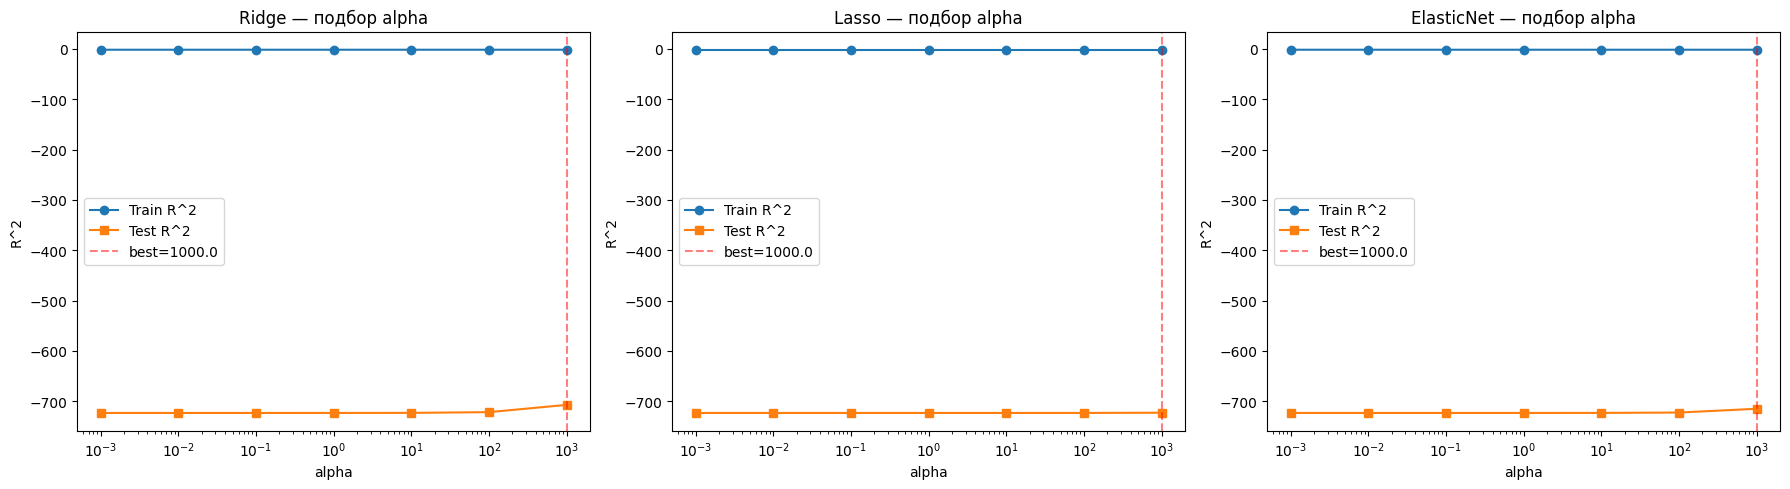


Лучшие параметры alpha:
Ridge: alpha=1000.0, Test R^2=-707.103689957366
Lasso: alpha=1000.0, Test R^2=-722.6949399953805
ElasticNet: alpha=1000.0, Test R^2=-714.8555223612789


In [151]:
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_for_alpha = [
    ('Ridge', MyRidge, {'learning_rate': 1e-8, 'n_epochs': 1000}),
    ('Lasso', MyLasso, {'learning_rate': 1e-8, 'n_epochs': 1000}),
    ('ElasticNet', MyElasticNet, {'learning_rate': 1e-8, 'n_epochs': 1000})
]

best_params = {}

for ax, (model_name, ModelClass, extra_params) in zip(axes, models_for_alpha):
    train_r2s, test_r2s = [], []
    best_alpha, best_r2 = None, -np.inf
    
    for alpha in alphas:
        model = ModelClass(alpha=alpha, random_state=42, **extra_params)
        model.fit(X_train_poly_s, y_train)
        r2_tr = r2_score_custom(y_train, model.predict(X_train_poly_s))
        r2_te = r2_score_custom(y_test, model.predict(X_test_poly_s))
        train_r2s.append(r2_tr)
        test_r2s.append(r2_te)
        if r2_te > best_r2:
            best_r2 = r2_te
            best_alpha = alpha
    
    best_params[model_name] = (best_alpha, best_r2)
    
    ax.plot(alphas, train_r2s, 'o-', label='Train R^2')
    ax.plot(alphas, test_r2s, 's-', label='Test R^2')
    ax.set_xscale('log')
    ax.set_xlabel('alpha')
    ax.set_ylabel('R^2')
    ax.set_title(f'{model_name} — подбор alpha')
    ax.legend()
    ax.axvline(best_alpha, color='red', linestyle='--', alpha=0.5, label=f'best={best_alpha}')
    ax.legend()

plt.tight_layout()
plt.show()

print("\nЛучшие параметры alpha:")
for name, (alpha, r2) in best_params.items():
    print(f"{name}: alpha={alpha}, Test R^2={r2}")

In [152]:
for name, (best_alpha, _) in best_params.items():
    if name == 'Ridge':
        model = MyRidge(alpha=best_alpha, learning_rate=1e-8, n_epochs=1000)
    elif name == 'Lasso':
        model = MyLasso(alpha=best_alpha, learning_rate=1e-8, n_epochs=1000)
    else:
        model = MyElasticNet(alpha=best_alpha, learning_rate=1e-8, n_epochs=1000)
    
    model.fit(X_train_poly_s, y_train)
    y_tr = model.predict(X_train_poly_s)
    y_te = model.predict(X_test_poly_s)
    add_metrics(f'{name} (poly10, best alpha={best_alpha})', y_train, y_tr, y_test, y_te)

# 9. Наивные модели (Native models)

In [153]:
y_train_mean_pred = np.full_like(y_train, y_train.mean(), dtype=np.float64)
y_test_mean_pred = np.full_like(y_test, y_train.mean(), dtype=np.float64)
add_metrics('Среднее (наивная модель)', y_train, y_train_mean_pred, y_test, y_test_mean_pred)

y_train_median_pred = np.full_like(y_train, np.median(y_train), dtype=np.float64)
y_test_median_pred = np.full_like(y_test, np.median(y_train), dtype=np.float64)
add_metrics('Медиана (наивная модель)', y_train, y_train_median_pred, y_test, y_test_median_pred)

# 10. Сравнение результатов (Compare results)

## 10.1. Итоговые таблицы

In [154]:
print("-" * 57)
print("ИТОГОВЫЕ ТАБЛИЦЫ")
print("-" * 57)
print_metrics_dataframe()

---------------------------------------------------------
ИТОГОВЫЕ ТАБЛИЦЫ
---------------------------------------------------------
Таблица MAE:


,model,train,test
0,Моя линейная регрессия (SGD),713.312606,717.714093
1,Линейная регрессия sklearn,707.909104,711.554486
2,Моя Ridge,713.302463,717.700010
3,Моя Lasso,713.312607,717.714091
4,Моя ElasticNet,713.307520,717.707046
5,Sklearn Ridge,707.905486,711.549247
6,Sklearn Lasso,707.579943,711.022037
7,Sklearn ElasticNet,804.922313,800.657346
8,My LR + MinMax,719.490217,722.513401
9,My Ridge + MinMax,719.531378,722.498927



Таблица RMSE:


,model,train,test
0,Моя линейная регрессия (SGD),1029.707959,1048.684380
1,Линейная регрессия sklearn,1023.913834,1041.003012
2,Моя Ridge,1029.695964,1048.663083
3,Моя Lasso,1029.707957,1048.684377
4,Моя ElasticNet,1029.701948,1048.673717
5,Sklearn Ridge,1023.913842,1040.998445
6,Sklearn Lasso,1024.111354,1041.064394
7,Sklearn ElasticNet,1179.739784,1176.860719
8,My LR + MinMax,1028.996366,1045.972781
9,My Ridge + MinMax,1028.977446,1045.719953



Таблица R^2:


,model,train,test
0,Моя линейная регрессия (SGD),0.579913,0.555566
1,Линейная регрессия sklearn,0.584628,0.562053
2,Моя Ridge,0.579923,0.555584
3,Моя Lasso,0.579913,0.555566
4,Моя ElasticNet,0.579918,0.555575
5,Sklearn Ridge,0.584628,0.562057
6,Sklearn Lasso,0.584467,0.562001
7,Sklearn ElasticNet,0.448579,0.440284
8,My LR + MinMax,0.580494,0.557861
9,My Ridge + MinMax,0.580509,0.558075


## 10.1-2. Лучшая и наиболее стабильная модель

**Лучшая модель** - та, которая показывает наивысший $R^2$ на тестовой выборке. Такова регуляризованная по Lasso линейная регрессия от sklearn, обучения на нормализованных по MinMax признаках ("sk Lasso + MinMax" в моей итоговой таблице), с показателем $R^2$ 0.562329 на тестовой выборке. Из моих моделей наилучшая - Ridge, обученная на нормализованных по MinMax признаках ( $R^2$ на тестовой выборке - 0.558075)	

**Наиболее стабильная модель** - та, у которой разница между метриками на train и test минимальна. Это говорит о том, что модель хорошо обобщает и не переобучается. Среди моделей показатели отставания $R^2$ на тестовой выборке от него же на обучающей приблизительно одинаковые (примерно 0.02), так что можно выбрать наилучшую модель (которая здесь не исключение) и как самую стабильную. Хотя можно было бы вывести наиболее стабильную модель автоматически, мне кажется, задание этого не подразумевает.

Наивные модели работают очень плохо, хуже, чем остальные (не считая полиномиальных). Значит, признаки отрабатывают хорошо.